In [1]:
%reload_ext autoreload
%autoreload 2

import pickle
import numpy as np
import healpy as hp
import json
from scipy import interpolate

from fpp.utils.validation import roc_finite_sample_band
from fpp.utils.posterior import multi_corner

import jax.numpy as jnp
import jax


import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

In [2]:
from fpp.models.np_model import NPModel

In [3]:
data = jnp.array(np.load("../outputs/production/simulations/nmold-2.npy")[0], dtype=jnp.int32)

m = NPModel(data=data)

In [4]:
truth = json.load(open('../outputs/truths/truth_dict_base230927.json', 'r'))
for k, v in truth.items():
    if isinstance(v, list):
        truth[k] = np.array(v)
truth['theta_pib'] = np.array([1 - 2e-10, 1e-10, 1e-10])
truth['theta_ics'] = np.array([1 - 2e-10, 1e-10, 1e-10])
truth['theta_bulge_poiss'] = np.array([1 - 4e-10, 1e-10, 1e-10, 1e-10, 1e-10])
truth['theta_bulge_ps'] = np.array([1e-10, 1 - 4e-10, 1e-10, 1e-10, 1e-10])

In [5]:
from numpyro.infer.util import constrain_fn, unconstrain_fn

model_static_kwargs = {"data": data}

In [6]:
init_unconstrained = unconstrain_fn(
    m.model, model_args=(), model_kwargs=model_static_kwargs,
    params=truth
)
# For multiple chains, replicate:
# init_params = jax.tree.map(lambda x: jnp.broadcast_to(x, (num_chains, *x.shape)), init_unconstrained)

In [ ]:
init_unconstrained

In [7]:
from numpyro.infer import MCMC, NUTS

In [12]:
kernel = NUTS(m.model, max_tree_depth=4, dense_mass=False, step_size=0.05)
m.nuts_mcmc = MCMC(kernel, num_warmup=0, num_samples=1000, num_chains=1, chain_method='vectorized')
m.nuts_mcmc.run(jax.random.PRNGKey(0), init_params=init_unconstrained, **model_static_kwargs)

sample: 100%|██████████| 1000/1000 [01:10<00:00, 14.22it/s, 3 steps of size 5.00e-02. acc. prob=0.05]


In [14]:
s = m.nuts_mcmc.get_samples()

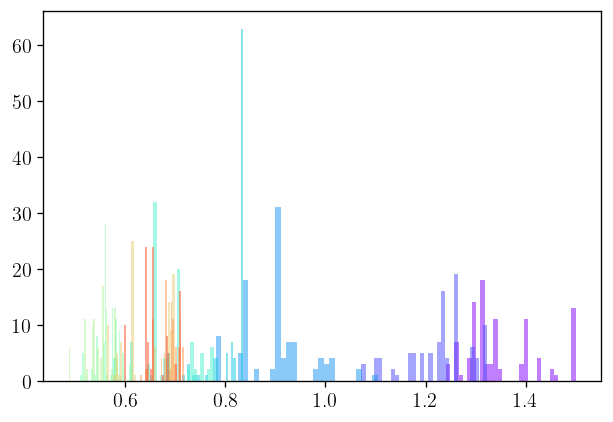

In [16]:
for i in range(10):
    color = plt.cm.rainbow(i / 10)
    plt.hist(s['Sps_gce'][i*100:(i+1)*100], bins=30, alpha=0.5, color=color, label=f'Chain {i}');

In [17]:
def pp_finite_sample_band(n_samples, mc_samples=10000):
    """Using MC, find the 95% containment band for ROC curve for a gaussian distribution."""
    invcdf_arr = []
    for _ in range(mc_samples):
        x_sample = np.random.normal(size=n_samples)
        p_sample = special.erf(np.abs(x_sample)/np.sqrt(2))
        invcdf_arr.append(np.sort(p_sample))
    invcdf_arr = np.array(invcdf_arr)
    invcdf_upper = np.quantile(invcdf_arr, 0.975, axis=0)
    invcdf_lower = np.quantile(invcdf_arr, 0.025, axis=0)
    return invcdf_lower, invcdf_upper

In [20]:
from scipy import special

In [18]:
def pp_finite_sample_band_triangle(n_samples, mc_samples=10000):
    """95% containment band for the P-P plot of a symmetric triangular likelihood."""
    invcdf_arr = []
    for _ in range(mc_samples):
        # Sample from symmetric triangular distribution on [-1, 1]
        x_sample = np.random.triangular(-1, 0, 1, size=n_samples)
        # Credible level at which the true value (0) is just contained
        p_sample = 1 - (1 - np.abs(x_sample))**2
        invcdf_arr.append(np.sort(p_sample))
    invcdf_arr = np.array(invcdf_arr)
    invcdf_upper = np.quantile(invcdf_arr, 0.975, axis=0)
    invcdf_lower = np.quantile(invcdf_arr, 0.025, axis=0)
    return invcdf_lower, invcdf_upper

In [ ]:
from scipy import stats

def pp_finite_sample_band_asym_triangle(n_samples, mc_samples=10000):
    """95% containment band for the P-P plot of an asymmetric triangular likelihood."""
    tri_dist = stats.triang(c=1/3, loc=-0.5, scale=1.5)  # mode at 0, support [-0.5, 1]

    def hpd_credible_level(x_vals):
        """For each x, find the fraction of the posterior with density >= f(x)."""
        f_at_x = tri_dist.pdf(x_vals)
        # For each threshold f*, the HPD content is P(f(X) >= f*)
        # which is the CDF of f(X). We compute this by finding the
        # two roots where f(t) = f(x) and integrating the parts above.
        p_vals = np.empty_like(x_vals)
        for i, fx in enumerate(tqdm(f_at_x)):
            if fx >= 4/3 - 1e-12:  # at the mode
                p_vals[i] = 0.0
            elif fx < 1e-12:  # at the boundary
                p_vals[i] = 1.0
            else:
                # Find all t where f(t) = fx
                # Left branch: 2(t+0.5)/0.75 = fx -> t = 0.75*fx/2 - 0.5
                # Right branch: 2(1-t)/1.5 = fx -> t = 1 - 1.5*fx/2
                t_left = 0.75 * fx / 2 - 0.5
                t_right = 1 - 1.5 * fx / 2
                # HPD region is [t_left, t_right], content is CDF(t_right) - CDF(t_left)
                p_vals[i] = tri_dist.cdf(t_right) - tri_dist.cdf(t_left)
        return p_vals

    invcdf_arr = []
    for _ in range(mc_samples):
        x_sample = tri_dist.rvs(size=n_samples)
        p_sample = hpd_credible_level(x_sample)
        invcdf_arr.append(np.sort(p_sample))
    invcdf_arr = np.array(invcdf_arr)
    invcdf_upper = np.quantile(invcdf_arr, 0.975, axis=0)
    invcdf_lower = np.quantile(invcdf_arr, 0.025, axis=0)
    return invcdf_lower, invcdf_upper

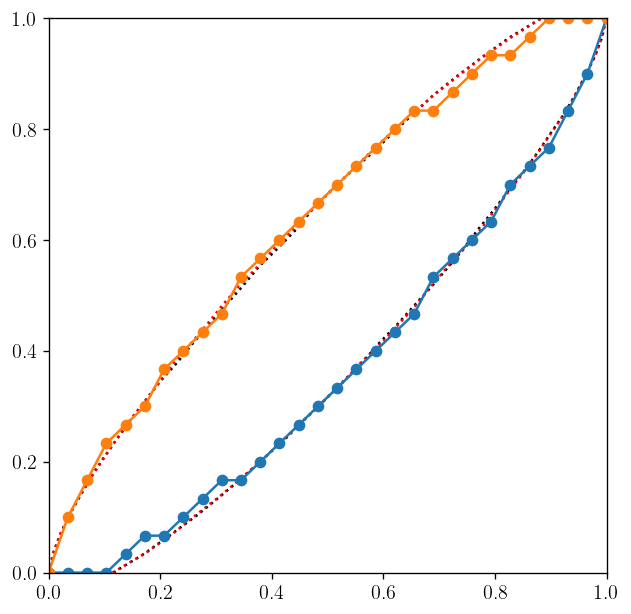

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))
n_run = 30
invcdf_lower, invcdf_upper = pp_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')
invcdf_lower, invcdf_upper = pp_finite_sample_band_triangle(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'r:')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'r:')
# invcdf_lower, invcdf_upper = pp_finite_sample_band_asym_triangle(n_run)
# ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'b:')
# ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'b:')
ax.set(xlim=(0, 1), ylim=(0, 1))

p_in = np.linspace(0, 1, n_run)
p_out_low = []
p_out_high = []
for p in p_in:
    thresh_low, thresh_high = binomial_threshold(n_run, p)
    p_out_low.append(thresh_low/n_run)
    p_out_high.append(thresh_high/n_run)

ax.plot(p_in, p_out_low, 'o-', label='Lower Bound')
ax.plot(p_in, p_out_high, 'o-', label='Upper Bound')

In [26]:
.7**10

0.028247524899999984

In [36]:
from scipy import stats

def binomial_threshold(n, p):
    """Find the largest k such that P(X <= k) > 0.975 for X ~ Binomial(n, p)."""
    return stats.binom.ppf(0.025, n, p), stats.binom.ppf(0.975, n, p)

In [30]:
p_in = np.linspace(0, 1, 10)
p_out = []
for p in p_in:
    thresh = binomial_threshold(10, p)
    p_out.append(thresh/10)

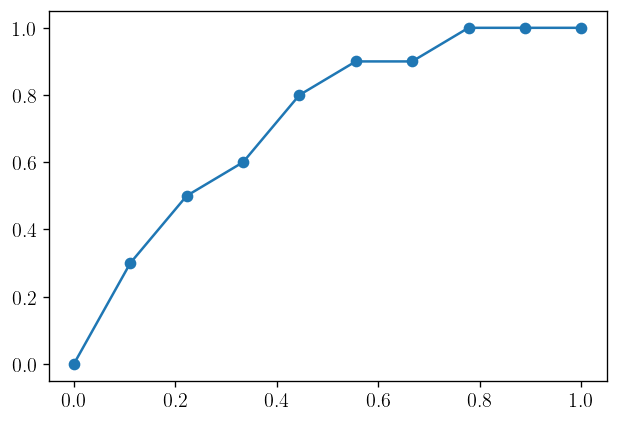

In [31]:
plt.plot(p_in, p_out, 'o-')